In [1]:
# Examples for manuscript

import numpy as np

from plots import (
    plot_results_for_doc,
    plot_bars,
    plot_lag2,
)

from pathlib import Path

# Compliance minimization

## Example 1

In [1]:
!mpirun -np 4 python test.py 01 > ../results/t01/out.txt

In [6]:
!head -n 12 ../results/t01/out.txt

Info    : Reading '../results/t01/domain.msh'...
Info    : 13 entities
Info    : 10675 nodes
Info    : 21020 elements
Info    : Done reading '../results/t01/domain.msh'

	Symmetric Cantilever 2D - Data Parallelism

> Path = ../results/t01
> Nbr of triangles = 20946
> Iterations:
i =   0 | cost = 2.7139 | cstr = 1.5925 | nder = 5.3727 | steps =  0 | lagr = 2.7139 | lm = 0.0000 | mu = 0.0000


In [7]:
!tail -n 5 ../results/t01/out.txt

i =  49 | cost = 2.1841 | cstr = 0.9986 | nder = 0.3614 | steps = 16 | lagr = 2.1815 | lm = 1.8436 | mu = 1.8464
i =  50 | cost = 2.1835 | cstr = 0.9993 | nder = 0.3696 | steps = 16 | lagr = 2.1822 | lm = 1.8436 | mu = 1.8451
> Stopping condition reached!
> Assembly time = 9.78156009899999 s
> Resolution time = 6.164058263000015 s


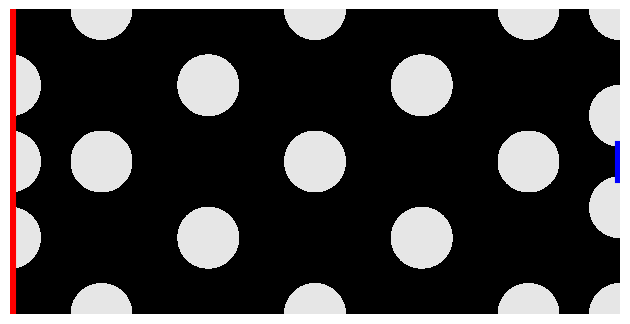

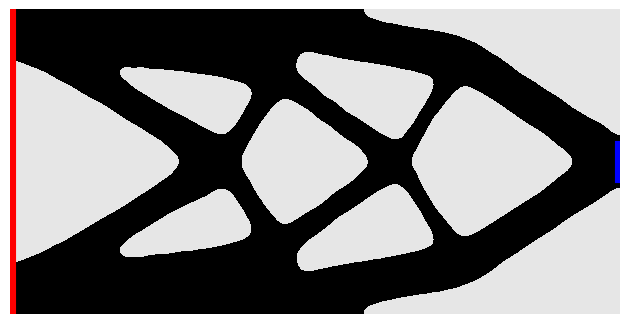

In [8]:
test_path = Path("../results/t01/")

vertices = np.array(
    [
        (0.0, 0.0),
        (2.0, 0.0),
        (2.0, 0.45),
        (2.0, 0.55),
        (2.0, 1.0),
        (0.0, 1.0),
        (0.0, 0.0),
    ]
)

dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2

dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu = np.array(vertices[(neu_idx[0] - 1) : (neu_idx[-1] + 1)])
boundaries = [(dir, "red"), (neu, "blue")]

plot_results_for_doc(
    test_path, 0, [[0, 2], [0, 1]], 8, Path("../tex/compli1_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 49, [[0, 2], [0, 1]], 8, Path("../tex/compli1_1.png"), boundaries
)

## Example 3

In [9]:
!mpirun -np 2 python test.py 03 > ../results/t03/out.txt

In [10]:
!head -n 12 ../results/t03/out.txt

Info    : Reading '../results/t03/domain.msh'...
Info    : 13 entities
Info    : 8382 nodes
Info    : 16527 elements
Info    : Done reading '../results/t03/domain.msh'

	Multiple load cases - Data Parallelism

> Path = ../results/t03
> Nbr of triangles = 16425
> Iterations:
i =   0 | cost = 1.8159 | cstr = 1.4398 | nder = 5.1839 | steps =  0 | lagr = 1.8159 | lm = 0.0000 | mu = 0.0000


In [11]:
!tail -n 12 ../results/t03/out.txt

i =  62 | cost = 1.4359 | cstr = 1.0029 | nder = 1.3513 | steps = 16 | lagr = 1.4400 | lm = 1.3953 | mu = 1.3895
i =  63 | cost = 1.4321 | cstr = 1.0064 | nder = 1.3561 | steps = 16 | lagr = 1.4410 | lm = 1.4050 | mu = 1.3922
i =  64 | cost = 1.4346 | cstr = 1.0043 | nder = 1.3573 | steps = 15 | lagr = 1.4407 | lm = 1.4069 | mu = 1.3982
i =  65 | cost = 1.4322 | cstr = 1.0068 | nder = 1.3657 | steps = 16 | lagr = 1.4417 | lm = 1.4158 | mu = 1.4023
i =  66 | cost = 1.4335 | cstr = 1.0044 | nder = 1.3610 | steps = 15 | lagr = 1.4397 | lm = 1.4174 | mu = 1.4086
i =  67 | cost = 1.4373 | cstr = 1.0019 | nder = 1.3625 | steps = 16 | lagr = 1.4399 | lm = 1.4164 | mu = 1.4127
i =  68 | cost = 1.4379 | cstr = 1.0023 | nder = 1.3709 | steps = 15 | lagr = 1.4412 | lm = 1.4191 | mu = 1.4145
i =  69 | cost = 1.4376 | cstr = 1.0021 | nder = 1.3715 | steps = 16 | lagr = 1.4406 | lm = 1.4208 | mu = 1.4166
i =  70 | cost = 1.4381 | cstr = 1.0005 | nder = 1.3705 | steps = 16 | lagr = 1.4387 | lm = 1.41

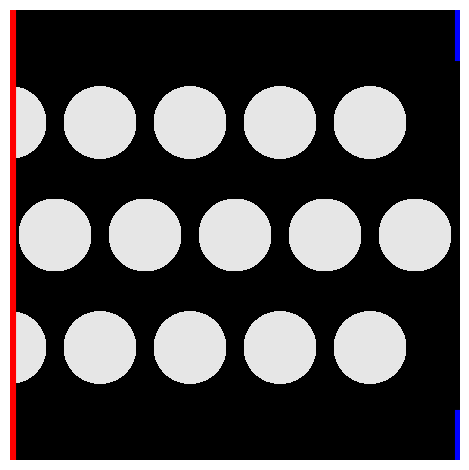

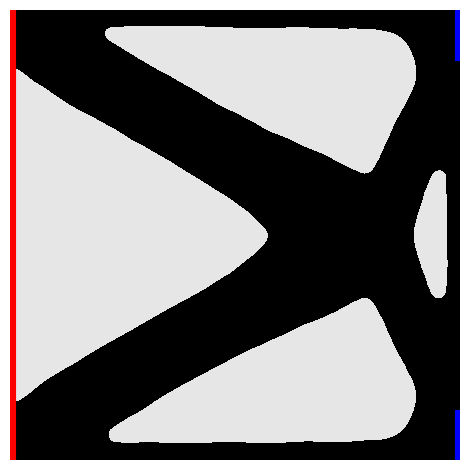

In [13]:
test_path = Path("../results/t03/")

vertices = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [1.0, 0.1],
        [1.0, 0.9],
        [1.0, 1.0],
        [0.0, 1.0],
        [0.0, 0.0],
    ]
)

dir_idx, dir_mkr = [6], 1
neu_idx_bot, neu_mkr_bot = [2], 2
neu_idx_top, neu_mkr_top = [4], 3

boundary_parts = [
    (dir_idx, dir_mkr, "dir"),
    (neu_idx_bot, neu_mkr_bot, "neu_bot"),
    (neu_idx_top, neu_mkr_top, "neu_top"),
]

dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu_bot = np.array(vertices[(neu_idx_bot[0] - 1) : (neu_idx_bot[-1] + 1)])
neu_top = np.array(vertices[(neu_idx_top[0] - 1) : (neu_idx_top[-1] + 1)])
boundaries = [(dir, "red"), (neu_bot, "blue"), (neu_top, "blue")]

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 8, Path("../tex/compli3_0.png"), boundaries
)

last_iter = 70
plot_results_for_doc(
    test_path,
    last_iter,
    [[0, 1], [0, 1]],
    8,
    Path("../tex/compli3_1.png"),
    boundaries,
)


## Example 4

In [1]:
!mpirun -np 2 python test.py 18 > ../results/t18/out.txt

In [2]:
!mpirun -np 2 python test.py 19 > ../results/t19/out.txt

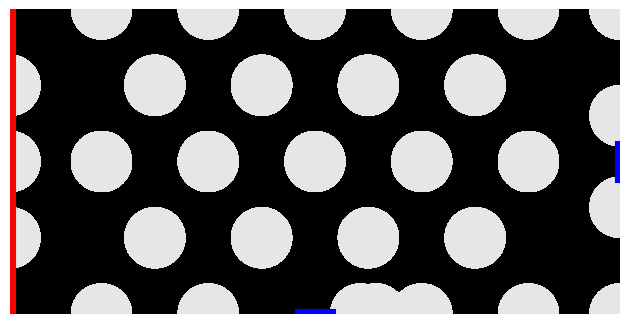

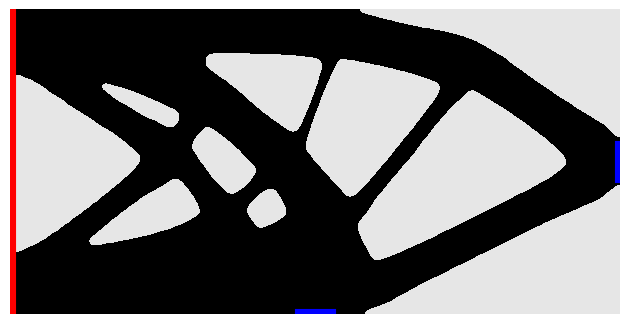

In [5]:
test_path = Path("../results/t18/")

vertices = np.array(
    [
        [0.0, 0.0],
        [0.95, 0.0],
        [1.05, 0.0],
        [2.0, 0.0],
        [2.0, 0.45],
        [2.0, 0.55],
        [2.0, 1.0],
        [0.0, 1.0],
        [0.0, 0.0],
    ]
)

dir_idx, dir_mkr = [8], 1
neu_idx_bot, neu_mkr_bot = [2], 2
neu_idx_right, neu_mkr_right = [5], 3

dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu_bot = np.array(vertices[(neu_idx_bot[0] - 1) : (neu_idx_bot[-1] + 1)])
neu_right = np.array(vertices[(neu_idx_right[0] - 1) : (neu_idx_right[-1] + 1)])
boundaries = [(dir, "red"), (neu_bot, "blue"), (neu_right, "blue")]

plot_results_for_doc(
    test_path, 0, [[0, 2], [0, 1]], 8, Path("../tex/compli4_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 79, [[0, 2], [0, 1]], 8, Path("../tex/compli4_1.png"), boundaries
)

# Inverse elasticity

## Example 1

### Data parallelism

In [81]:
!mpirun -np 6 python test.py 06 > ../results/t06/out.txt

In [82]:
!head -n 15 ../results/t06/out.txt

Info    : Reading '../results/t06/domain0.msh'...
Info    : 281 entities
Info    : 19336 nodes
Info    : 38670 elements
Info    : Done reading '../results/t06/domain0.msh'
Info    : Reading '../results/t06/domain.msh'...
Info    : 161 entities
Info    : 6503 nodes
Info    : 13004 elements
Info    : Done reading '../results/t06/domain.msh'

	Elasticity Inverse Problem - Data Parallelism

> Path = ../results/t06
> Nbr of triangles = 12713


In [83]:
!tail -n 5 ../results/t06/out.txt

i = 123 | cost = 0.000008 | nder = 0.0006 | steps = 15 | 
i = 124 | cost = 0.000008 | nder = 0.0006 | steps = 15 | 
> Stopping condition reached!
> Assembly time = 19.128951690999997 s
> Resolution time = 33.108504890000006 s


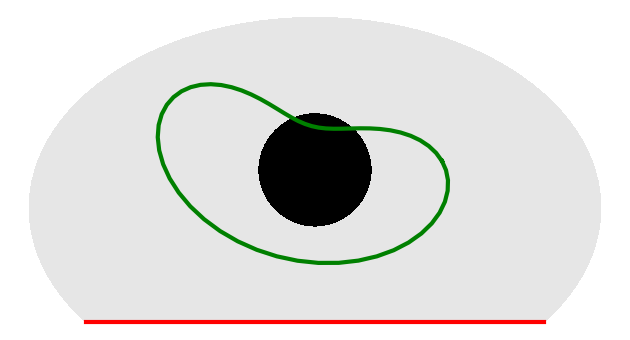

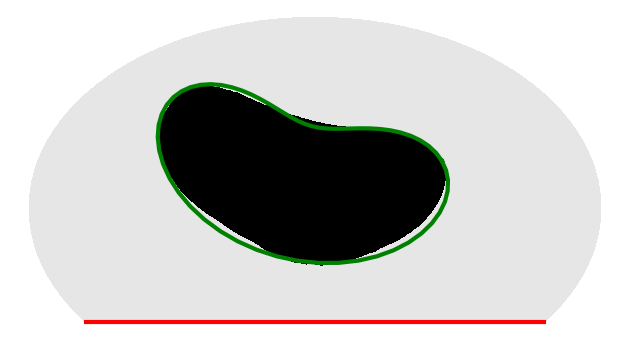

In [41]:
test_path = Path("../results/t06/")

def semi_ellipse(a, b, eps, npts):
    """
    Coordinates of a ellipse
    crossing the x-axis
    """
    t_ = np.arcsin((b - eps) / b)
    t = np.linspace(-t_, np.pi + t_, npts)
    x = a * np.cos(t)
    y = b * np.sin(t) + (b - eps)
    return x, y

npts = 80
part = npts // 4

vertices = np.column_stack(semi_ellipse(0.75, 0.5, 0.2, npts))

dir_idx, dir_mkr = [npts], 1
bR_idx, bR_mkr = np.arange(1, part // 2 + 1), 2
neu_idxA, neu_mkrA = part // 2 + np.arange(1, part + 1), 3
neu_idxB, neu_mkrB = part // 2 + np.arange(part + 1, 2 * part + 1), 4
neu_idxC, neu_mkrC = part // 2 + np.arange(2 * part + 1, 3 * part + 1), 5
bL_idx, bL_mkr = np.arange(part // 2 + 3 * part + 1, npts), 6

vertices = np.concatenate((vertices, [vertices[0]]))
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
bR = np.array(vertices[(bR_idx[0] - 1) : (bR_idx[-1] + 1)])
neuA = np.array(vertices[(neu_idxA[0] - 1) : (neu_idxA[-1] + 1)])
neuB = np.array(vertices[(neu_idxB[0] - 1) : (neu_idxB[-1] + 1)])
neuC = np.array(vertices[(neu_idxC[0] - 1) : (neu_idxC[-1] + 1)])
bL = np.array(vertices[(bL_idx[0] - 1) : (bL_idx[-1] + 1)])

sd = np.load(test_path / "subdomain.npy")
sd = np.vstack((sd, sd[0]))

# (bR, "yellow"),
# (neuA, "blue"),
# (neuB, "green"),
# (neuC, "orange"),
# (bL, "yellow"),
boundaries = [
    (dir, "red"),
    (sd, "green")
]

plot_results_for_doc(
    test_path, 0, [[-0.8, 0.8], [-0.02, 0.82]], 3, Path("../tex/inv1_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 124, [[-0.8, 0.8], [-0.02, 0.82]], 3, Path("../tex/inv1_1.png"), boundaries,
)

### Task parallelism

In [84]:
!mpirun -np 6 python test.py 07 > ../results/t07/out.txt

In [85]:
!head -n 40 ../results/t07/out.txt

Info    : Reading '../results/t07/domain0.msh'...
Info    : 281 entities
Info    : 19336 nodes
Info    : 38670 elements
Info    : Done reading '../results/t07/domain0.msh'
Info    : Reading '../results/t07/domain.msh'...
Info    : 161 entities
Info    : 6503 nodes
Info    : Reading '../results/t07/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t07/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t07/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t07/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t07/domain.msh'...
Info    : 161 entities
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 13004 elements
Info    : 13004 elements
Info    : 13004 elements
Info    : 13004 elements
Info    : 13004 elements
Info    : 13004 elements
Info    : Done reading '../results/t07/domain.msh'
Info    : Done reading '../results/t07/domain.msh'
Info    : Done rea

In [86]:
!tail -n 5 ../results/t07/out.txt

i = 113 | cost = 0.000010 | nder = 0.0006 | steps = 16 | 
i = 114 | cost = 0.000010 | nder = 0.0009 | steps = 16 | 
> Stopping condition reached!
> Assembly time = 4.093016288000001 s
> Resolution time = 28.502968081000006 s


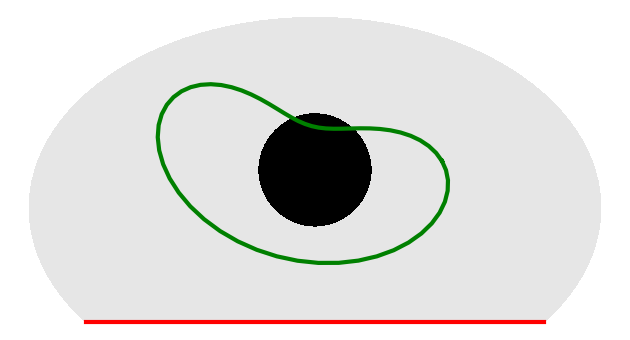

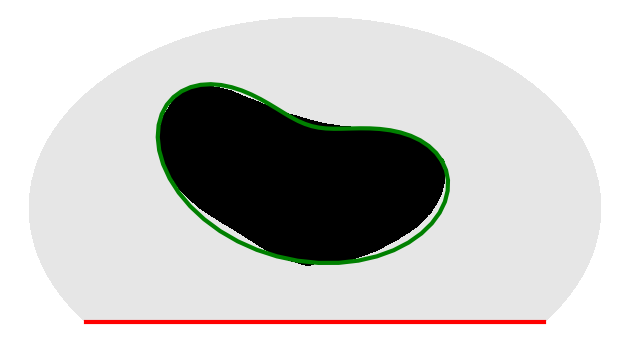

In [ ]:
test_path = Path("../results/t07/")

def semi_ellipse(a, b, eps, npts):
    """
    Coordinates of a ellipse
    crossing the x-axis
    """
    t_ = np.arcsin((b - eps) / b)
    t = np.linspace(-t_, np.pi + t_, npts)
    x = a * np.cos(t)
    y = b * np.sin(t) + (b - eps)
    return x, y

npts = 80
part = npts // 4

vertices = np.column_stack(semi_ellipse(0.75, 0.5, 0.2, npts))

dir_idx, dir_mkr = [npts], 1
bR_idx, bR_mkr = np.arange(1, part // 2 + 1), 2
neu_idxA, neu_mkrA = part // 2 + np.arange(1, part + 1), 3
neu_idxB, neu_mkrB = part // 2 + np.arange(part + 1, 2 * part + 1), 4
neu_idxC, neu_mkrC = part // 2 + np.arange(2 * part + 1, 3 * part + 1), 5
bL_idx, bL_mkr = np.arange(part // 2 + 3 * part + 1, npts), 6

vertices = np.concatenate((vertices, [vertices[0]]))
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
bR = np.array(vertices[(bR_idx[0] - 1) : (bR_idx[-1] + 1)])
neuA = np.array(vertices[(neu_idxA[0] - 1) : (neu_idxA[-1] + 1)])
neuB = np.array(vertices[(neu_idxB[0] - 1) : (neu_idxB[-1] + 1)])
neuC = np.array(vertices[(neu_idxC[0] - 1) : (neu_idxC[-1] + 1)])
bL = np.array(vertices[(bL_idx[0] - 1) : (bL_idx[-1] + 1)])

sd = np.load(test_path / "subdomain.npy")
sd = np.vstack((sd, sd[0]))

# (bR, "yellow"),
# (neuA, "blue"),
# (neuB, "green"),
# (neuC, "orange"),
# (bL, "yellow"),
boundaries = [
    (dir, "red"),
    (sd, "green")
]

plot_results_for_doc(
    test_path, 0, [[-0.8, 0.8], [-0.02, 0.82]], 3, Path("../tex/inv1_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 114, [[-0.8, 0.8], [-0.02, 0.82]], 3, Path("../tex/inv1_1.png"), boundaries,
)

### Mixed parallelism

In [87]:
!mpirun -np 12 python test.py 08 > ../results/t08/out.txt

In [88]:
!head -n 40 ../results/t08/out.txt

Info    : Reading '../results/t08/domain0.msh'...
Info    : 281 entities
Info    : 19336 nodes
Info    : 38670 elements
Info    : Done reading '../results/t08/domain0.msh'
Info    : Reading '../results/t08/domain.msh'...
Info    : 161 entities
Info    : 6503 nodes
Info    : Reading '../results/t08/domain.msh'...
Info    : 161 entities
Info    : 6503 nodes
Info    : 13004 elements
Info    : 13004 elements
Info    : Done reading '../results/t08/domain.msh'
Info    : Done reading '../results/t08/domain.msh'
Info    : Reading '../results/t08/domain.msh'...
Info    : Reading '../results/t08/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t08/domain.msh'...
Info    : 161 entities
Info    : 161 entities
Info    : Reading '../results/t08/domain.msh'...
Info    : 161 entities
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 6503 nodes
Info    : 13004 elements
Info    : 13004 elements
Info    : 13004 elements
Info    : 13004 elements
Info    : Done rea

In [89]:
!tail -n 5 ../results/t08/out.txt

i = 115 | cost = 0.000010 | nder = 0.0014 | steps = 16 | 
i = 116 | cost = 0.000011 | nder = 0.0016 | steps = 14 | 
> Stopping condition reached!
> Assembly time = 6.334670275999997 s
> Resolution time = 26.82384936899996 s


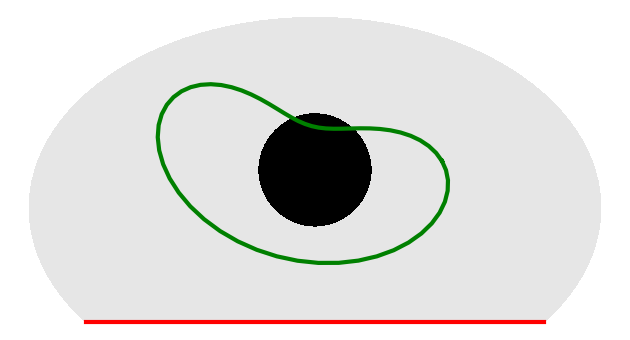

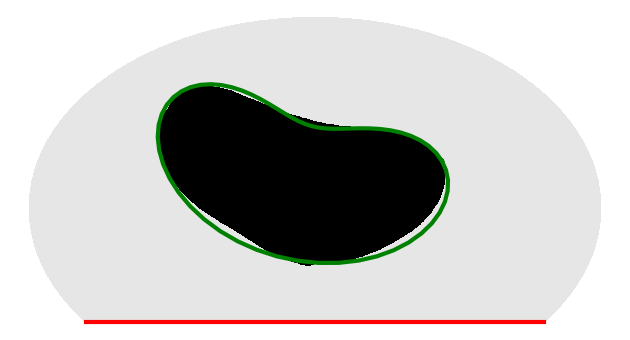

In [90]:
test_path = Path("../results/t08/")

def semi_ellipse(a, b, eps, npts):
    """
    Coordinates of a ellipse
    crossing the x-axis
    """
    t_ = np.arcsin((b - eps) / b)
    t = np.linspace(-t_, np.pi + t_, npts)
    x = a * np.cos(t)
    y = b * np.sin(t) + (b - eps)
    return x, y

npts = 80
part = npts // 4

vertices = np.column_stack(semi_ellipse(0.75, 0.5, 0.2, npts))

dir_idx, dir_mkr = [npts], 1
bR_idx, bR_mkr = np.arange(1, part // 2 + 1), 2
neu_idxA, neu_mkrA = part // 2 + np.arange(1, part + 1), 3
neu_idxB, neu_mkrB = part // 2 + np.arange(part + 1, 2 * part + 1), 4
neu_idxC, neu_mkrC = part // 2 + np.arange(2 * part + 1, 3 * part + 1), 5
bL_idx, bL_mkr = np.arange(part // 2 + 3 * part + 1, npts), 6

vertices = np.concatenate((vertices, [vertices[0]]))
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
bR = np.array(vertices[(bR_idx[0] - 1) : (bR_idx[-1] + 1)])
neuA = np.array(vertices[(neu_idxA[0] - 1) : (neu_idxA[-1] + 1)])
neuB = np.array(vertices[(neu_idxB[0] - 1) : (neu_idxB[-1] + 1)])
neuC = np.array(vertices[(neu_idxC[0] - 1) : (neu_idxC[-1] + 1)])
bL = np.array(vertices[(bL_idx[0] - 1) : (bL_idx[-1] + 1)])

sd = np.load(test_path / "subdomain.npy")
sd = np.vstack((sd, sd[0]))

# (bR, "yellow"),
# (neuA, "blue"),
# (neuB, "green"),
# (neuC, "orange"),
# (bL, "yellow"),
boundaries = [
    (dir, "red"),
    (sd, "green")
]

plot_results_for_doc(
    test_path, 0, [[-0.8, 0.8], [-0.02, 0.82]], 3, Path("../tex/inv1_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 116, [[-0.8, 0.8], [-0.02, 0.82]], 3, Path("../tex/inv1_1.png"), boundaries,
)

## Example 2

### Data parallelism

`mpirun -np 16 python test.py 34 > ../results/t34/out.txt`

In [78]:
!head -n 15 ../results/t34/out.txt

Info    : Reading '../results/t34/domain0.msh'...
Info    : 401 entities
Info    : 21054 nodes
Info    : 42106 elements
Info    : Done reading '../results/t34/domain0.msh'
Info    : Reading '../results/t34/domain.msh'...
Info    : 161 entities
Info    : 6845 nodes
Info    : 13688 elements
Info    : Done reading '../results/t34/domain.msh'

	Elasticity Inverse Problem (two inclusions) - Data Parallelism

> Path = ../results/t34
> Nbr of triangles = 13391


In [79]:
!tail -n 5 ../results/t34/out.txt

i = 173 | cost = 0.000021 | nder = 0.0008 | steps = 16 | 
i = 174 | cost = 0.000021 | nder = 0.0008 | steps = 16 | 
> Stopping condition reached!
> Assembly time = 0.5817101400002684 s
> Resolution time = 145.86537488099975 s


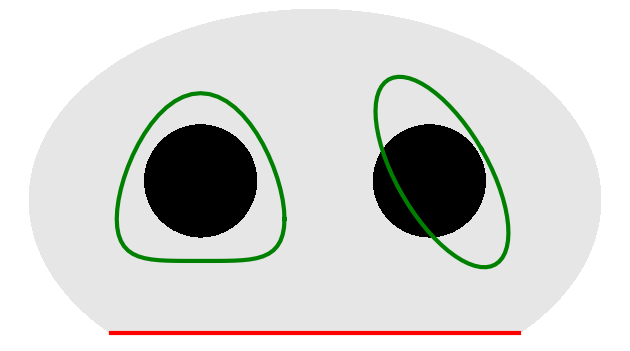

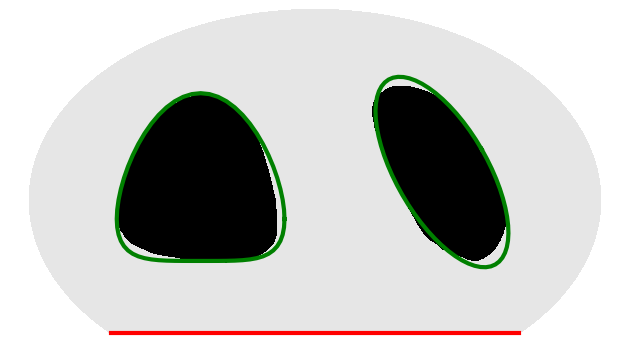

In [80]:
test_path = Path("../results/t34/")

def semi_ellipse(a, b, eps, npts):
    """
    Coordinates of a ellipse
    crossing the x-axis
    """
    t_ = np.arcsin((b - eps) / b)
    t = np.linspace(-t_, np.pi + t_, npts)
    x = a * np.cos(t)
    y = b * np.sin(t) + (b - eps)
    return x, y

npts = 80
part = npts // 8

vertices = np.column_stack(semi_ellipse(0.75, 0.5, 0.15, npts))

dir_idx, dir_mkr = [npts], 1
vertices = np.concatenate((vertices, [vertices[0]]))
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])

sd1 = np.load(test_path / "inclusion1.npy")
sd1 = np.vstack((sd1, sd1[0]))
sd2 = np.load(test_path / "inclusion2.npy")
sd2 = np.vstack((sd2, sd2[0]))

boundaries = [
    (dir, "red"),
    (sd1, "green"),
    (sd2, "green")
]

plot_results_for_doc(
    test_path, 0, [[-0.8, 0.8], [-0.02, 0.85]], 3, Path("../tex/inv2_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 174, [[-0.8, 0.8], [-0.02, 0.85]], 3, Path("../tex/inv2_1.png"), boundaries,
)

### Task parallelism

`mpirun -np 16 python test.py 35 > ../results/t35/out.txt`

In [3]:
!head -n 95 ../results/t35/out.txt

Info    : Reading '../results/t35/domain0.msh'...
Info    : 401 entities
Info    : 21054 nodes
Info    : 42106 elements
Info    : Done reading '../results/t35/domain0.msh'
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : 6845 nodes
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t35/domain.msh'...
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : 161 entities
Info    : 6845 nodes
Info    : 6845 nodes
Info    : 6845 nodes
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : 13688 elements
Info    : 6845 nodes
Info    : Reading '../results/t35/domain.msh'...
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t35/domain.msh'...
Info    : 161 entities
Info    : Reading '../results/t35/domain.msh'...
Info    : Reading '../re

In [4]:
!tail -n 5 ../results/t35/out.txt

i = 172 | cost = 0.000021 | nder = 0.0008 | steps = 16 | 
i = 173 | cost = 0.000021 | nder = 0.0008 | steps = 16 | 
> Stopping condition reached!
> Assembly time = 0.10725097899990033 s
> Resolution time = 682.6483243499999 s


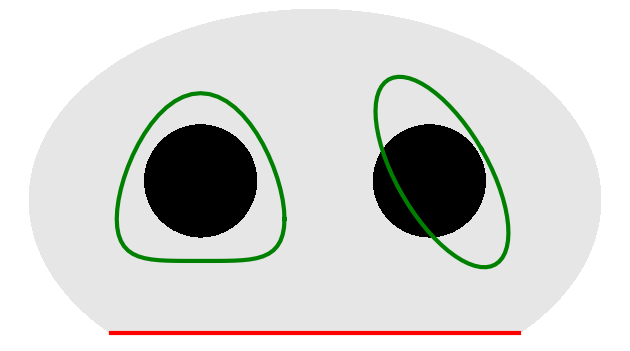

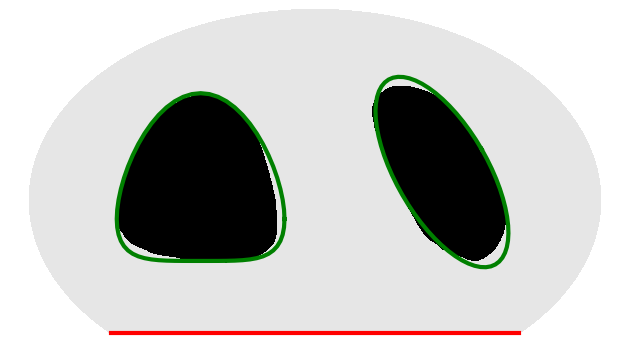

In [6]:
test_path = Path("../results/t35/")

def semi_ellipse(a, b, eps, npts):
    """
    Coordinates of a ellipse
    crossing the x-axis
    """
    t_ = np.arcsin((b - eps) / b)
    t = np.linspace(-t_, np.pi + t_, npts)
    x = a * np.cos(t)
    y = b * np.sin(t) + (b - eps)
    return x, y

npts = 80
part = npts // 8

vertices = np.column_stack(semi_ellipse(0.75, 0.5, 0.15, npts))

dir_idx, dir_mkr = [npts], 1
vertices = np.concatenate((vertices, [vertices[0]]))
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])

sd1 = np.load(test_path / "inclusion1.npy")
sd1 = np.vstack((sd1, sd1[0]))
sd2 = np.load(test_path / "inclusion2.npy")
sd2 = np.vstack((sd2, sd2[0]))

boundaries = [
    (dir, "red"),
    (sd1, "green"),
    (sd2, "green")
]

plot_results_for_doc(
    test_path, 0, [[-0.8, 0.8], [-0.02, 0.85]], 3, Path("../tex/inv2_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 173, [[-0.8, 0.8], [-0.02, 0.85]], 3, Path("../tex/inv2_1.png"), boundaries,
)

### Mixed parallelism

`mpirun -np 32 python test.py 36 > ../results/t36/out.txt`

In [ ]:
!head -n 45 ../results/t36/out.txt

In [7]:
!tail -n 5 ../results/t36/out.txt

i = 173 | cost = 0.000021 | nder = 0.0008 | steps = 16 | 
i = 174 | cost = 0.000021 | nder = 0.0008 | steps = 16 | 
> Stopping condition reached!
> Assembly time = 0.12776431899999352 s
> Resolution time = 43.20877414900008 s


# Heat conduction

## Example 1

In [1]:
!mpirun -np 2 python test.py 09 > ../results/t09/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


In [10]:
!head -n 10 ../results/t09/out.txt

Info    : Reading '../results/t09/domain.msh'...
Info    : 13 entities
Info    : 46692 nodes
Info    : 92622 elements
Info    : Done reading '../results/t09/domain.msh'

	Heat conduction 1 - Data Parallelism

> Path = ../results/t09
> Nbr of triangles = 92582


In [3]:
!tail -n 5 ../results/t09/out.txt

i = 203 | cost = 2.2633 | cstr = 1.0015 | nder = 1.1815 | steps = 12 | lagr = 2.2664 | lm = 2.0091 | mu = 2.0060
i = 204 | cost = 2.2738 | cstr = 1.0000 | nder = 1.3003 | steps = 13 | lagr = 2.2738 | lm = 2.0073 | mu = 2.0073
> Stopping condition reached!
> Assembly time = 5.159827824999979 s
> Resolution time = 59.26874286000009 s


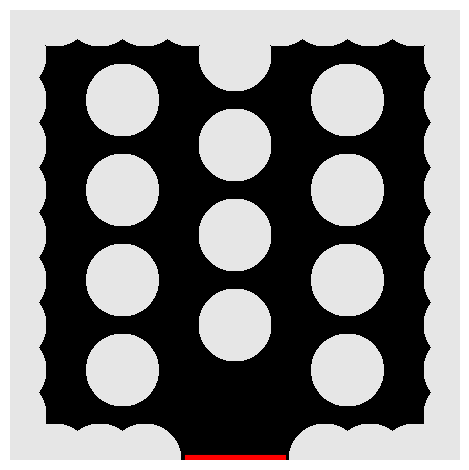

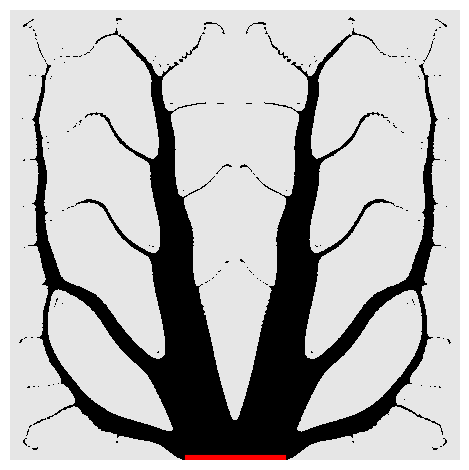

In [6]:
test_path = Path("../results/t09/")

vertices = [[0.0, 0.0], [0.4, 0.0], [0.6, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]
dir_idx, dir_mkr = [2], 1
vertices = vertices + [vertices[0]]
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
boundaries = [(dir, "red")]

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 8, Path("../tex/heat1_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 204, [[0, 1], [0, 1]], 8, Path("../tex/heat1_1.png"), boundaries,
)

## Example 2

In [12]:
!mpirun -np 4 python test.py 10 > ../results/t10/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


In [17]:
!head -n 10 ../results/t10/out.txt

Info    : Reading '../results/t10/domain.msh'...
Info    : 9 entities
Info    : 72857 nodes
Info    : 145712 elements
Info    : Done reading '../results/t10/domain.msh'                                                               

	Heat conduction 2 - Data Parallelism

> Path = ../results/t10
> Nbr of triangles = 144712


In [14]:
!tail -n 5 ../results/t10/out.txt

i = 171 | cost = 0.0892 | cstr = 0.9990 | nder = 0.0710 | steps = 16 | lagr = 0.0890 | lm = 0.2113 | mu = 0.2133
i = 172 | cost = 0.0895 | cstr = 0.9994 | nder = 0.0759 | steps = 16 | lagr = 0.0893 | lm = 0.2112 | mu = 0.2124
> Stopping condition reached!
> Assembly time = 5.443556976000082 s
> Resolution time = 51.588608643999805 s


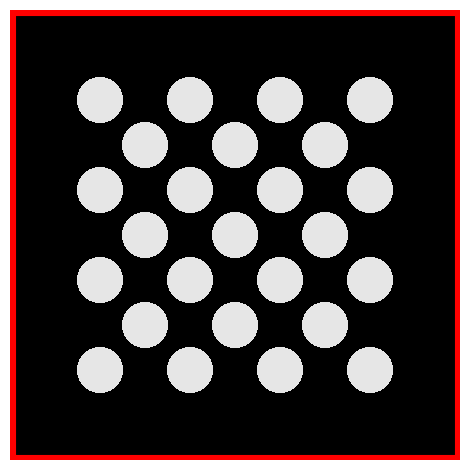

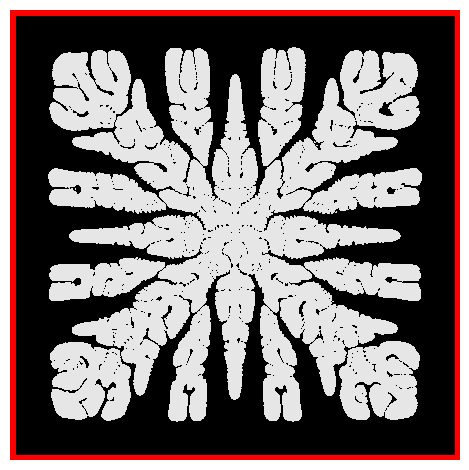

In [15]:
test_path = Path("../results/t10/")

vertices = [[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]
vertices = vertices + [vertices[0]]
dir = np.array(vertices)
boundaries = [(dir, "red")]

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 8, Path("../tex/heat2_0.png"), boundaries
)
plot_results_for_doc(
    test_path, 172, [[0, 1], [0, 1]], 8, Path("../tex/heat2_1.png"), boundaries
)

## Example 3

In [16]:
!mpirun -np 6 python test.py 11 > ../results/t11/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


In [18]:
!head -n 10 ../results/t11/out.txt

Info    : Reading '../results/t11/domain.msh'...
Info    : 9 entities
Info    : 11827 nodes
Info    : 23652 elements
Info    : Done reading '../results/t11/domain.msh'

	Heat conduction with one source - Data Parallelism

> Path = ../results/t11
> Nbr of triangles = 23252


In [21]:
!tail -n 5 ../results/t11/out.txt

i = 180 | cost = 0.1054 | cstr = 1.0013 | nder = 0.0138 | steps = 16 | lagr = 0.1055 | lm = 0.0803 | mu = 0.0777
i = 181 | cost = 0.1054 | cstr = 1.0008 | nder = 0.0138 | steps = 16 | lagr = 0.1055 | lm = 0.0805 | mu = 0.0788
> Stopping condition reached!
> Assembly time = 8.405165570999998 s
> Resolution time = 10.490343062999955 s


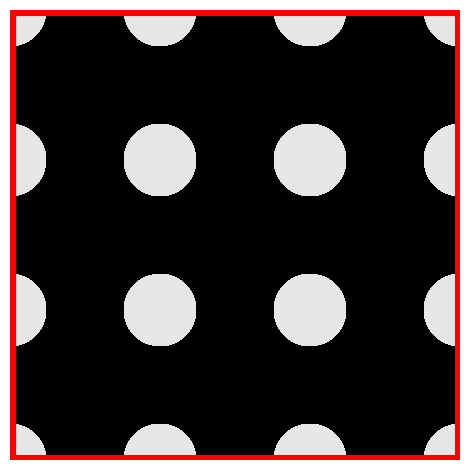

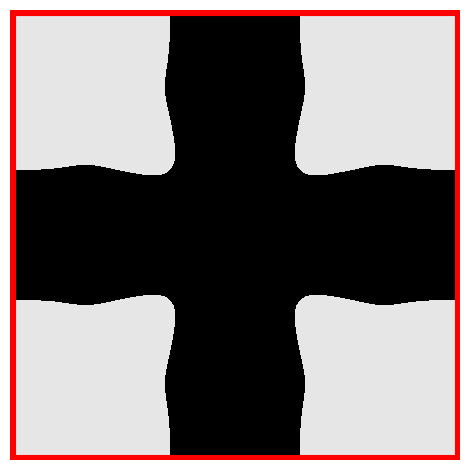

In [3]:
test_path = Path("../results/t11/")

vertices = [[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]
vertices = vertices + [vertices[0]]
dir = np.array(vertices)
boundaries = [(dir, "red")]

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 8, Path("../tex/heat3_0.png"), boundaries
)
plot_results_for_doc(
    test_path, 181, [[0, 1], [0, 1]], 8, Path("../tex/heat3_1.png"), boundaries
)


## Example 4

In [22]:
!mpirun -np 2 python test.py 12 > ../results/t12/out.txt

In [24]:
!head -n 10 ../results/t12/out.txt

Info    : Reading '../results/t12/domain.msh'...
Info    : 17 entities
Info    : 46707 nodes
Info    : 92692 elements
Info    : Done reading '../results/t12/domain.msh'

	Heat conduction with two sinks (single) - Data Parallelism

> Path = ../results/t12
> Nbr of triangles = 92612


In [25]:
!tail -n 5 ../results/t12/out.txt

i = 214 | cost = 0.7156 | cstr = 0.9973 | nder = 0.3001 | steps = 14 | lagr = 0.7138 | lm = 0.6847 | mu = 0.6902
i = 215 | cost = 0.7123 | cstr = 1.0001 | nder = 0.3032 | steps = 15 | lagr = 0.7123 | lm = 0.6881 | mu = 0.6880
> Stopping condition reached!
> Assembly time = 5.342004296999903 s
> Resolution time = 69.32646820800005 s


In [23]:
!mpirun -np 2 python test.py 13 > ../results/t13/out.txt

In [27]:
!head -n 15 ../results/t13/out.txt

Info    : Reading '../results/t13/domain.msh'...
Info    : 17 entities
Info    : 46707 nodes
Info    : Reading '../results/t13/domain.msh'...
Info    : 17 entities
Info    : 46707 nodes
Info    : 92692 elements
Info    : 92692 elements
Info    : Done reading '../results/t13/domain.msh'
Info    : Done reading '../results/t13/domain.msh'

	Heat conduction with two sinks (multiple) - Task Parallelism

> Path = ../results/t13
> Nbr of triangles = 92612


In [28]:
!tail -n 5 ../results/t13/out.txt

i = 198 | cost = 1.4427 | cstr = 0.9985 | nder = 0.9807 | steps = 14 | lagr = 1.4393 | lm = 2.2767 | mu = 2.2797
i = 199 | cost = 1.4391 | cstr = 0.9996 | nder = 0.9725 | steps = 14 | lagr = 1.4381 | lm = 2.2776 | mu = 2.2784
> Stopping condition reached!
> Assembly time = 3.68095186000005 s
> Resolution time = 105.64981910200004 s


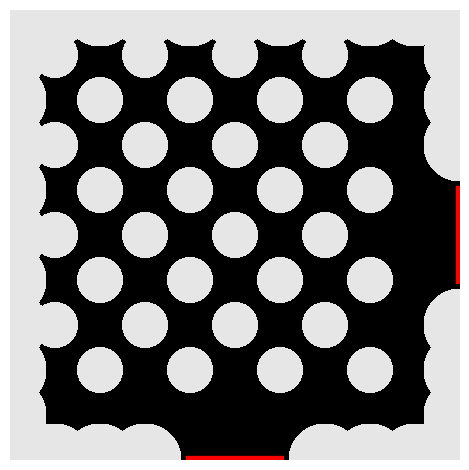

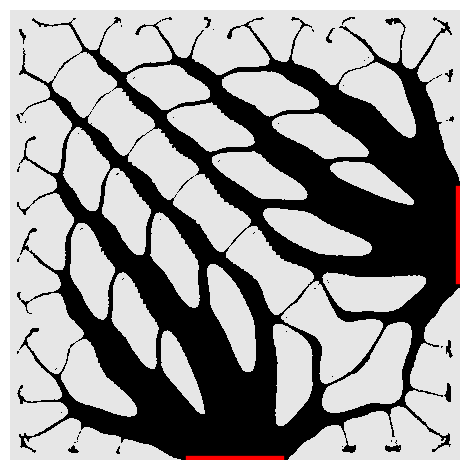

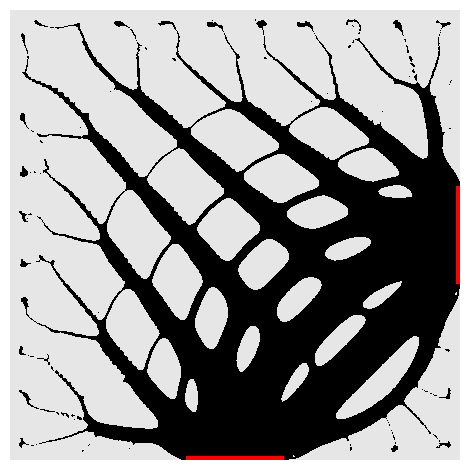

In [30]:
test_path = Path("../results/t12/")

vertices = [
    [0.0, 0.0],
    [0.4, 0.0],
    [0.6, 0.0],
    [1.0, 0.0],
    [1.0, 0.4],
    [1.0, 0.6],
    [1.0, 1.0],
    [0.0, 1.0],
]

dir1_idx, dir1_mkr = [2], 1
dir2_idx, dir2_mkr = [5], 2

dir1 = np.array(vertices[(dir1_idx[0] - 1) : (dir1_idx[-1] + 1)])
dir2 = np.array(vertices[(dir2_idx[0] - 1) : (dir2_idx[-1] + 1)])

boundaries = [(dir1, "red"), (dir2, "red")]

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 6, Path("../tex/heat4_0.png"), boundaries
)

plot_results_for_doc(
    test_path, 215, [[0, 1], [0, 1]], 6, Path("../tex/heat4_2.png"), boundaries
)

test_path = Path("../results/t13/")
plot_results_for_doc(
    test_path, 199, [[0, 1], [0, 1]], 6, Path("../tex/heat4_3.png"), boundaries
)

plot_lag2(
    np.load("../results/t13/data.npz")["cost"],
    "Multiple",
    np.load("../results/t12/data.npz")["cost"],
    "Simple",
    ylimits=(0, 3.5),
    figsize=(4.0, 4.0),
    filename=Path("../tex/heat4_1.png"),
)

## Example 5

In [1]:
!mpirun -np 2 python test.py 21 > ../results/t21/out.txt

In [2]:
!head -n 10 ../results/t21/out.txt

Info    : Reading '../results/t21/domain.msh'...
Info    : 17 entities
Info    : 11800 nodes
Info    : 23238 elements
Info    : Done reading '../results/t21/domain.msh'

	Heat conduction with four sources (single) - Data Parallelism

> Path = ../results/t21
> Nbr of triangles = 23206


In [3]:
!tail -n 5 ../results/t21/out.txt

i =  79 | cost = 0.1421 | cstr = 0.9997 | nder = 0.0413 | steps = 16 | lagr = 0.1421 | lm = 0.1067 | mu = 0.1074
i =  80 | cost = 0.1419 | cstr = 0.9999 | nder = 0.0407 | steps = 16 | lagr = 0.1419 | lm = 0.1068 | mu = 0.1071
> Stopping condition reached!
> Assembly time = 7.583934923000015 s
> Resolution time = 15.235008393000044 s


In [32]:
!mpirun -np 4 python test.py 22 > ../results/t22/out.txt

X_ChangeProperty: BadValue (integer parameter out of range for operation) 0x0


In [38]:
!head -n 25 ../results/t22/out.txt

Info    : Reading '../results/t22/domain.msh'...
Info    : 17 entities
Info    : 11800 nodes
Info    : Reading '../results/t22/domain.msh'...
Info    : Reading '../results/t22/domain.msh'...
Info    : Reading '../results/t22/domain.msh'...
Info    : 17 entities
Info    : 17 entities
Info    : 17 entities
Info    : 11800 nodes
Info    : 11800 nodes
Info    : 11800 nodes
Info    : 23238 elements
Info    : 23238 elements
Info    : 23238 elements
Info    : 23238 elements
Info    : Done reading '../results/t22/domain.msh'
Info    : Done reading '../results/t22/domain.msh'
Info    : Done reading '../results/t22/domain.msh'
Info    : Done reading '../results/t22/domain.msh'

	Heat conduction with four sources (multiple) - Task Parallelism

> Path = ../results/t22
> Nbr of triangles = 23206


In [39]:
!tail -n 5 ../results/t22/out.txt

i =  62 | cost = 0.2945 | cstr = 0.9968 | nder = 0.2719 | steps = 16 | lagr = 0.2899 | lm = 1.4203 | mu = 1.4268
i =  63 | cost = 0.2935 | cstr = 0.9991 | nder = 0.4434 | steps = 16 | lagr = 0.2922 | lm = 1.4220 | mu = 1.4238
> Stopping condition reached!
> Assembly time = 5.125252800999988 s
> Resolution time = 19.509336899000118 s


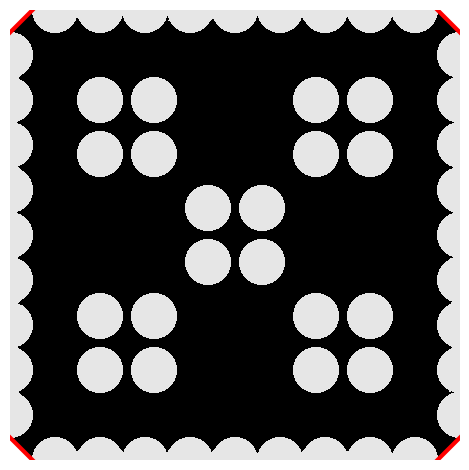

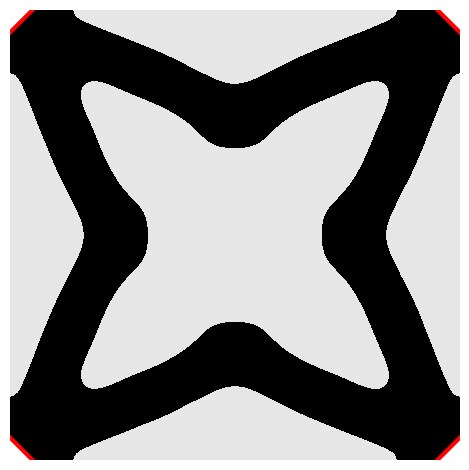

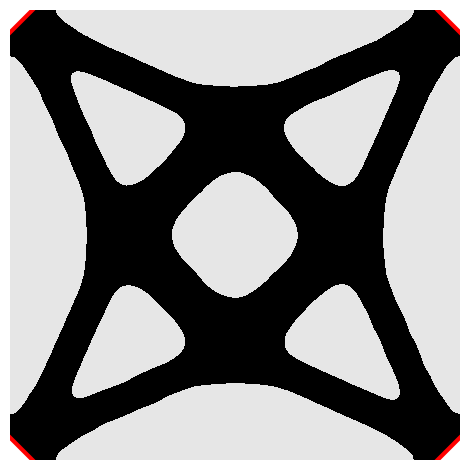

In [6]:
test_path = Path("../results/t21/")

vertices = np.array(
    [
        [0.05, 0.0],
        [0.95, 0.0],
        [1.0, 0.05],
        [1.0, 0.95],
        [0.95, 1.0],
        [0.05, 1.0],
        [0.0, 0.95],
        [0.0, 0.05],
        [0.05, 0.0],
    ]
)

dir1_idx, dir1_mkr = [2], 1
dir2_idx, dir2_mkr = [4], 2
dir3_idx, dir3_mkr = [6], 3
dir4_idx, dir4_mkr = [8], 4

dir1 = np.array(vertices[(dir1_idx[0] - 1) : (dir1_idx[-1] + 1)])
dir2 = np.array(vertices[(dir2_idx[0] - 1) : (dir2_idx[-1] + 1)])
dir3 = np.array(vertices[(dir3_idx[0] - 1) : (dir3_idx[-1] + 1)])
dir4 = np.array(vertices[(dir4_idx[0] - 1) : (dir4_idx[-1] + 1)])

boundaries = [(dir1, "red"), (dir2, "red"), (dir3, "red"), (dir4, "red")]

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 3, Path("../tex/heat5_0.png"), boundaries
)
plot_results_for_doc(
    test_path, 80, [[0, 1], [0, 1]], 3, Path("../tex/heat5_2.png"), boundaries
)

test_path = Path("../results/t22/")
plot_results_for_doc(
    test_path, 63, [[0, 1], [0, 1]], 3, Path("../tex/heat5_3.png"), boundaries
)

plot_lag2(
    np.load("../results/t22/data.npz")["cost"],
    "Multiple",
    np.load("../results/t21/data.npz")["cost"],
    "Simple",
    ylimits=(0, 0.4),
    figsize=(4.0, 4.0),
    filename=Path("../tex/heat5_1.png"),
)


# Population dynamics

## Example 1

In [3]:
!mpirun -np 2 python test.py 14 > ../results/t14/out.txt

In [9]:
!head -n 7 ../results/t14/out.txt

Info    : Reading '../results/t14/domain.msh'...
Info    : 9 entities
Info    : 8356 nodes
Info    : 16710 elements
Info    : Done reading '../results/t14/domain.msh'
> Iterations:
i =   0 | cost = -0.0203 | cstr = 1.0014 | nder = 0.0200 | steps =  0 | lagr = -0.0203 | lm = 0.0000 | mu = 0.0000


In [10]:
!tail -n 5 ../results/t14/out.txt

i = 146 | cost = -0.1540 | cstr = 1.0003 | nder = 0.0071 | steps = 16 | lagr = -0.1539 | lm = 0.3181 | mu = 0.3174
i = 147 | cost = -0.1538 | cstr = 0.9997 | nder = 0.0072 | steps = 16 | lagr = -0.1539 | lm = 0.3172 | mu = 0.3177
> Stopping condition reached!
> Assembly time = 8.711127910999949 s
> Resolution time = 36.69884774399998 s


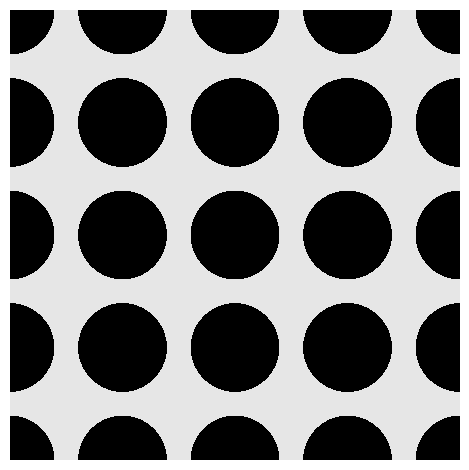

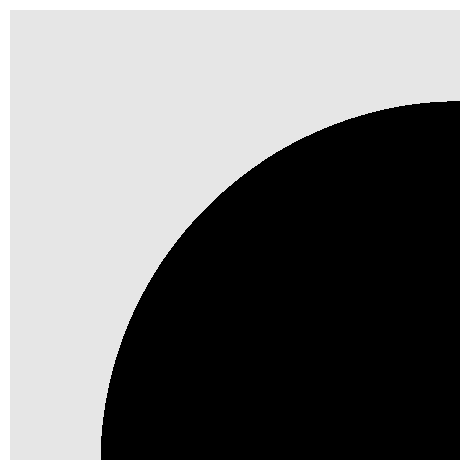

In [8]:
test_path = Path("../results/t14/")

plot_results_for_doc(
    test_path, 0, [[0, 1], [0, 1]], 3, Path("../tex/log1_0.png")
)
plot_results_for_doc(
    test_path, 147, [[0, 1], [0, 1]], 3, Path("../tex/log1_1.png")
)

In [11]:
!mpirun -np 2 python test.py 15 > ../results/t15/out.txt

In [12]:
!head -n 7 ../results/t15/out.txt

Info    : Reading '../results/t15/domain.msh'...
Info    : 9 entities
Info    : 8356 nodes
Info    : 16710 elements
Info    : Done reading '../results/t15/domain.msh'
> Iterations:
i =   0 | cost = -0.0217 | cstr = 1.0014 | nder = 0.0236 | steps =  0 | lagr = -0.0217 | lm = 0.0000 | mu = 0.0000


In [13]:
!tail -n 5 ../results/t15/out.txt

i = 106 | cost = -0.3572 | cstr = 0.9998 | nder = 0.0057 | steps = 16 | lagr = -0.3573 | lm = 0.5049 | mu = 0.5053
i = 107 | cost = -0.3573 | cstr = 0.9997 | nder = 0.0057 | steps = 16 | lagr = -0.3575 | lm = 0.5045 | mu = 0.5051
> Stopping condition reached!
> Assembly time = 8.486438493000037 s
> Resolution time = 25.81937338499995 s


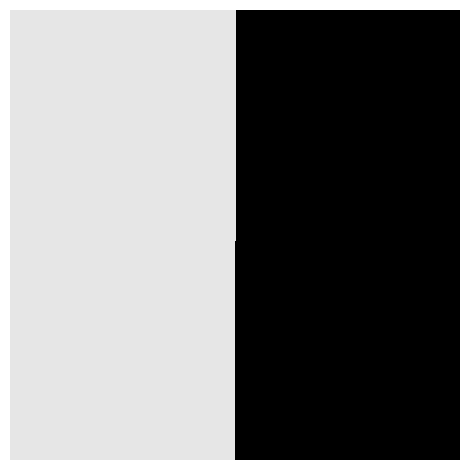

In [48]:
test_path = Path("../results/t15/")

plot_results_for_doc(
    test_path, 107, [[0, 1], [0, 1]], 3, Path("../tex/log1_2.png")
)

In [14]:
!mpirun -np 2 python test.py 16 > ../results/t16/out.txt

In [2]:
!head -n 7 ../results/t16/out.txt

Info    : Reading '../results/t16/domain.msh'...
Info    : 9 entities
Info    : 8356 nodes
Info    : 16710 elements
Info    : Done reading '../results/t16/domain.msh'
> Iterations:
i =   0 | cost = -0.0251 | cstr = 1.0014 | nder = 0.0331 | steps =  0 | lagr = -0.0251 | lm = 0.0000 | mu = 0.0000


In [15]:
!tail -n 5 ../results/t16/out.txt

i = 166 | cost = -0.3150 | cstr = 1.0001 | nder = 0.0077 | steps = 15 | lagr = -0.3150 | lm = 0.5214 | mu = 0.5212
i = 167 | cost = -0.3151 | cstr = 1.0001 | nder = 0.0078 | steps = 15 | lagr = -0.3150 | lm = 0.5215 | mu = 0.5213
> Stopping condition reached!
> Assembly time = 8.460277520999966 s
> Resolution time = 41.41813801700005 s


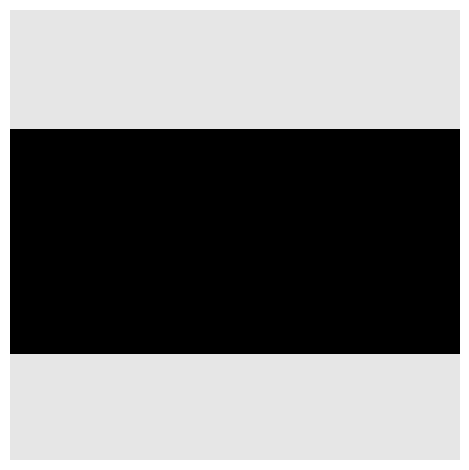

In [16]:
test_path = Path("../results/t16/")

plot_results_for_doc(
    test_path, 167, [[0, 1], [0, 1]], 3, Path("../tex/log1_3.png")
)

# Performance

## Example 1

```python
test_name = "Symmetric Cantilever 2D - Data Parallelism"
test_path = Path("../results/t38/")
dim = 2
rank_dim = 2
mesh_size = 0.0095
vertices = np.array(
    [(0.0, 0.0), (2.0, 0.0), (2.0, 0.45), (2.0, 0.55), (2.0, 1.0), (0.0, 1.0)]
)

dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2
boundary_parts = [(dir_idx, dir_mkr, "dir"), (neu_idx, neu_mkr, "neu")]

output = dib.create_domain_2d_DP(
    vertices, boundary_parts, mesh_size, path=test_path, plot=False
)

domain, nbr_tri, boundary_tags = output

if rank == 0:
    print("\n\t" + test_name + "\n")
    print(f"> Path = {test_path}")
    print(f"> Nbr of triangles = {nbr_tri}")

space = dib.create_space(domain, "CG", rank_dim)
dirichlet_bcs = dib.homogeneous_dirichlet(
    domain, space, boundary_tags, [dir_mkr], rank_dim
)
ds_g = dib.marked_ds(domain, boundary_tags, [neu_mkr])
area = 1.0
g = (0.0, -2.0)
md = Compliance(dim, domain, space, g, ds_g[0], dirichlet_bcs, area, test_path)

@dib.region_of(domain)
def sub_domain(x):
    # 0.42 < x[1] < 0.58
    # 1.95 < x[0]
    ineqs = [x[1] - 0.42, 0.58 - x[1], x[0] - 1.90]
    return ineqs

md.sub = [sub_domain.expression()]
centers = [(0.0, 0.5), (2.0, 0.35), (2.0, 0.65)]
centers += [((1 + i) * 0.25, 0.0) for i in range(8)]
centers += [(i * 0.5, 0.25) for i in range(5)]
centers += [(0.25 + i * 0.5, 0.5) for i in range(4)]
centers += [(i * 0.5, 0.75) for i in range(5)]
centers += [((1 + i) * 0.25, 1.0) for i in range(8)]
centers = np.array(centers)
radii = np.repeat(0.1, centers.shape[0])
md.create_initial_level(centers, radii)
md.save_initial_level(comm)
md.runDP(
    niter = 51,
    ctrn_tol=1e-3,
    dfactor=1e-1,
    reinit_step=4,
    reinit_pars=(15, 0.01),
    smooth=True,
)
```

In [26]:
# Number of triangles = 52085
#  1, 0.09985590600035721, 57.00270189399998
#  2, 0.09996008900020570, 36.68383217099995
#  3, 0.09941971400007787, 27.38364410600002
#  4, 0.08161376699990797, 19.11741326310820
#  5, 0.08064588099978210, 13.59849830069026
#  6, 0.07734192299994902, 11.11896835699985
#  7, 0.07839025799989940, 9.840473715999906
#  8, 0.07904987300003086, 8.914731048000021
#  9, 0.08507480599996597, 7.964109485999873
# 10, 0.08689052600004743, 7.503144190000057
# 11, 0.08182705399997303, 7.403827014999933
# 12, 0.08239540199997464, 6.448635795999962 

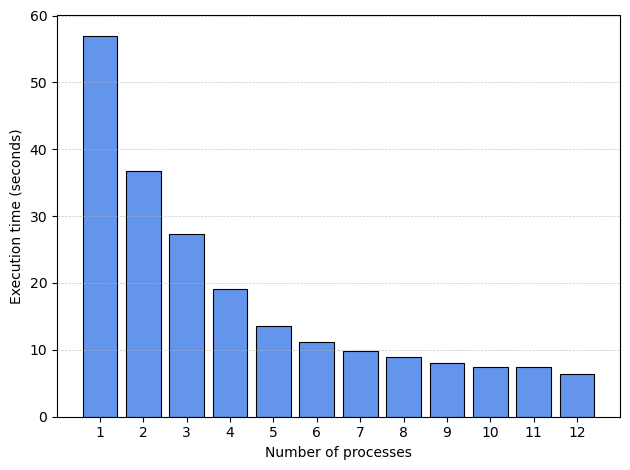

In [ ]:
filename = Path("../tex/performance_cant1.png")
num_procs = np.arange(1, 13)
resolution_times = [
    57.00270189399998,
    36.68383217099995,
    27.38364410600002,
    19.11741326310820,
    13.59849830069026,
    11.11896835699985,
    9.840473715999906,
    8.914731048000021,
    7.964109485999873,
    7.503144190000057,
    7.403827014999933,
    6.448635795999962
]
plot_bars(num_procs, resolution_times, filename, [0, 60])

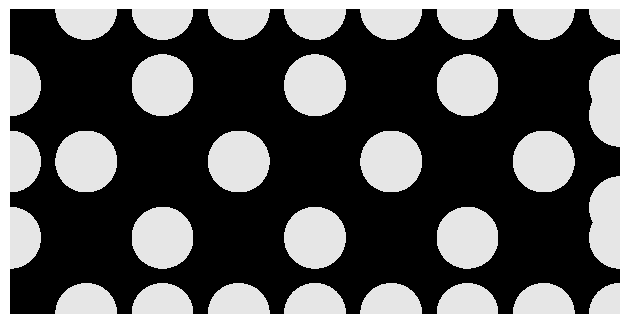

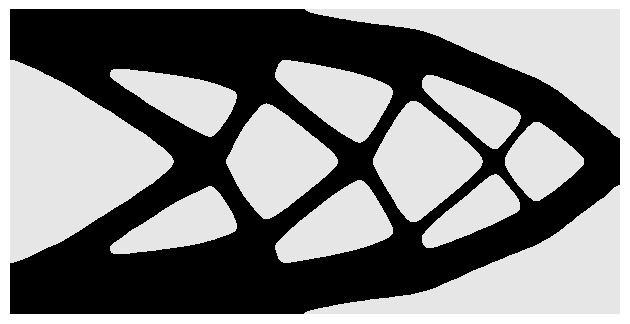

In [ ]:
test_path = Path("../results/t38/")

vertices = np.array(
    [
        (0.0, 0.0),
        (2.0, 0.0),
        (2.0, 0.45),
        (2.0, 0.55),
        (2.0, 1.0),
        (0.0, 1.0),
        (0.0, 0.0),
    ]
)

dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2

dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu = np.array(vertices[(neu_idx[0] - 1) : (neu_idx[-1] + 1)])
boundaries = [(dir, "red"), (neu, "deepskyblue")]

# plot_results_for_doc(
#     test_path, 0, [[0, 2], [0, 1]], 8, Path("../tex/perf_cant1_0.png")
# )

plot_results_for_doc(
    test_path, 46, [[0, 2], [0, 1]], 8, Path("../tex/perf_cant1_1.png")
)

## Example 2

In [29]:
# Number of triangles = 36375
#  1, 0.09625688099959007, 81.152981948999700
#  2, 0.09712492500011649, 47.295089525000094
#  3, 0.09320905200002016, 37.395500287000230
#  4, 0.92260369800033000, 23.900324507999812
#  5, 0.96088849099987780, 19.507271508000030
#  6, 0.91801393100013230, 17.290195303000020
#  7, 0.09122181899965653, 15.469340689000092
#  8, 0.96868140100013990, 14.818757753999762
#  9, 0.08950989999993908, 13.877525970000079
# 10, 0.92019453700004310, 13.712259119999999
# 11, 0.09089701399989280, 12.700247906000186
# 12, 0.09141436900006283, 11.857867510999995 

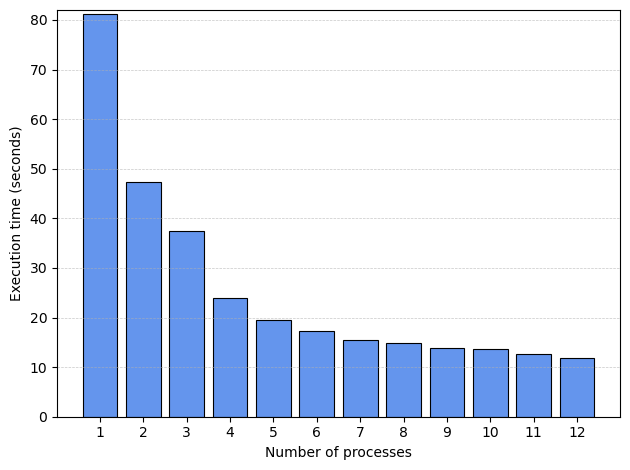

In [ ]:
filename = Path("../tex/performance_cant2.png")
num_procs = np.arange(1, 13)
resolution_times = [
    81.152981948999700,
    47.295089525000094,
    37.395500287000230,
    23.900324507999812,
    19.507271508000030,
    17.290195303000020,
    15.469340689000092,
    14.818757753999762,
    13.877525970000079,
    13.712259119999999,
    12.700247906000186,
    11.857867510999995
]
plot_bars(num_procs, resolution_times, filename, [0, 82])

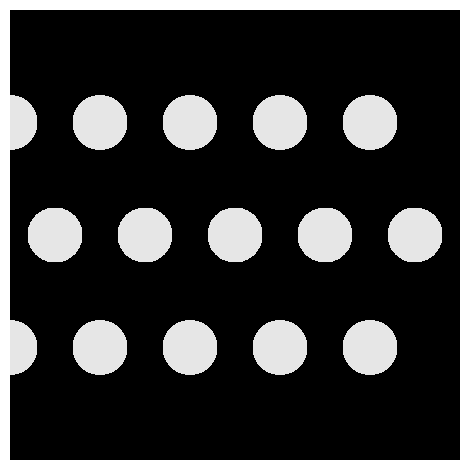

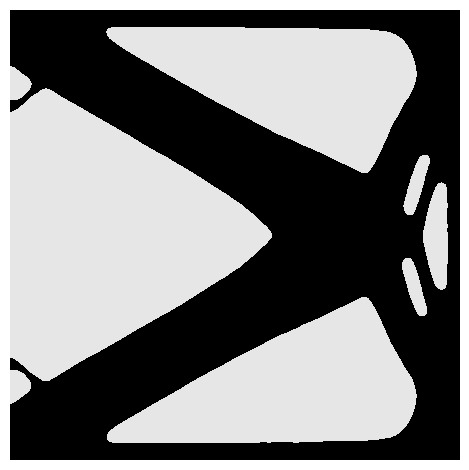

In [ ]:
test_path = Path("../results/t39/")

vertices = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [1.0, 0.1],
        [1.0, 0.9],
        [1.0, 1.0],
        [0.0, 1.0],
        [0.0, 0.0],
    ]
)

dir_idx, dir_mkr = [6], 1
neu_idx_bot, neu_mkr_bot = [2], 2
neu_idx_top, neu_mkr_top = [4], 3

dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu_bot = np.array(vertices[(neu_idx_bot[0] - 1) : (neu_idx_bot[-1] + 1)])
neu_top = np.array(vertices[(neu_idx_top[0] - 1) : (neu_idx_top[-1] + 1)])
boundaries = [(dir, "red"), (neu_bot, "deepskyblue"), (neu_top, "deepskyblue")]

# plot_results_for_doc(
#     test_path, 0, [[0, 1], [0, 1]], 8, Path("../tex/perf_cant2_0.png")
# )

plot_results_for_doc(
    test_path, 61, [[0, 1], [0, 1]], 8, Path("../tex/perf_cant2_1.png")
)